# Inspect direct-mDST parquet and test the GPT-like model

## Goal

This notebook is an executable tour of the `direct-mdst-tree-v1` parquet
produced by `scripts/preprocess_mdst.py`. It:

1. demonstrates the top-level, event, level, node, legacy, and summary records;
2. checks tree links, provenance IDs, numerical fields, and four-vector closure;
3. converts variable-width direct trees into a teacher-forced GPT-like batch;
4. runs `ParticleEmbedder` and `MultiGPT` on real preprocessed events; and
5. executes one CPU optimizer step to verify forward, loss, gradient, and update paths.

The neural networks are randomly initialized. Losses and predictions below are
software-integration diagnostics, **not physics-performance measurements**.

## Setup

Run with the project CPU environment:

```bash
source /data/dust/user/boyangyu/uv_env/bin/activate
```

Override the default parquet with `HYPERTAGGING_PREPROCESS_OUTPUT`.
The notebook uses four events for the model smoke test, so it remains safe on a
CPU login node.

In [1]:
from pathlib import Path
import json
import os

import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from hypertagging.data.direct_gpt import (
    DIRECT_FEATURE_NAMES,
    build_direct_multi_gpt_batch,
    collate_direct_gpt_events,
    load_direct_gpt_events,
)
from hypertagging.losses.gpt_losses import distance, radius_loss
from hypertagging.losses.link_losses import link_metrics
from hypertagging.models.gpt_like import MultiGPT, ParticleEmbedder

INPUT_PATH = Path(
    os.environ.get("HYPERTAGGING_PREPROCESS_OUTPUT", '/data/dust/user/boyangyu/hypertagging/preprocess_mc16ri_run2_100.parquet')
)
MANIFEST_SUMMARY_PATH = Path('/data/dust/user/boyangyu/hypertagging/production_10m/manifests/mdst_10m.summary.json')
MODEL_EVENT_LIMIT = 4
DEVICE = torch.device("cpu")
torch.manual_seed(7)
np.random.seed(7)

assert INPUT_PATH.exists(), f"Missing parquet: {INPUT_PATH}"
print(f"Input: {INPUT_PATH}")
print(f"PyTorch: {torch.__version__}; device: {DEVICE}; CUDA available: {torch.cuda.is_available()}")

Input: /data/dust/user/boyangyu/hypertagging/preprocess_mc16ri_run2_100.parquet
PyTorch: 2.13.0+cpu; device: cpu; CUDA available: False


## Steps

### 1. Load the parquet and inspect its top-level structure

In [2]:
awkward_payload = ak.from_parquet(INPUT_PATH)
payload = ak.to_list(awkward_payload)[0]
production_summary = json.loads(payload["summary_json"])

print("Awkward type:")
print(akward_type := ak.type(awkward_payload))
print("\nTop-level fields:", list(payload))
print("Schema version:", payload["schema_version"])
print("Events:", len(payload["events"]))
print("Legacy level rows:", len(payload["legacy_levels"]))

Awkward type:
1 * {schema_version: string, events: var * {event_id: int64, event_uid: string, experiment: int64, run: int64, production: int64, root_ids: var * int64, levels: var * {level: int64, node_ids: var * int64}, nodes: var * {node_id: int64, pdg: int64, token: int64, charge: float64, mass: float64, energy: float64, px: float64, py: float64, pz: float64, level: int64, parent_id: int64, daughter_ids: var * int64, reco_id: string, mc_id: int64, copied_from: int64, source_node_id: int64, flags: var * string, prodTime: float64, x: float64, y: float64, z: float64, nDaughters: int64, mc_px: ?float64, mc_py: ?float64, mc_pz: ?float64, mc_energy: ?float64}, metadata_json: string}, legacy_levels: var * {feature: var * var * float64, channel: int64, evtNum: int64, depth: int64, seq_len: int64, arrayIndex: var * int64, motherPDG: var * int64, motherIndex: var * int64, E_Rec: float64, targetNodeIds: var * int64}, summary_json: string}

Top-level fields: ['schema_version', 'events', 'legacy_

### 2. Inspect event, level, and node records

In [3]:
event = payload["events"][0]
event_overview = {
    key: event[key]
    for key in (
        "event_id",
        "event_uid",
        "experiment",
        "run",
        "production",
        "root_ids",
    )
}
display(pd.Series(event_overview, name="first event"))

display(pd.DataFrame(event["levels"]).rename(columns={"node_ids": "node_ids at level"}))

node_columns = [
    "node_id",
    "pdg",
    "token",
    "level",
    "parent_id",
    "daughter_ids",
    "reco_id",
    "energy",
    "px",
    "py",
    "pz",
    "mass",
    "mc_energy",
    "flags",
]
display(pd.DataFrame(event["nodes"])[node_columns].head(12))

event_id                                               76720263
event_uid                                 1004:0:76720263:52205
experiment                                                 1004
run                                                           0
production                                                52205
root_ids      [0, 4, 5, 8, 9, 29, 30, 31, 32, 33, 34, 35, 36...
Name: first event, dtype: object

,level,node_ids at level
0,0,"[3, 10, 11, 12, 13, 16, 18, 19, 21, 22, 23, 24..."
1,1,"[0, 5, 7, 9, 14, 15, 26]"
2,2,"[6, 8]"
3,3,[4]


,node_id,pdg,token,level,parent_id,daughter_ids,reco_id,energy,px,py,pz,mass,mc_energy,flags
0,0,11,24,1,-1,[3],,0.021763,0.007015,-0.020511,0.001931,2.659460e-10,7.003601,[truth_topology_only]
1,3,22,2,0,0,[],ECLCluster:13,0.021763,0.007015,-0.020511,0.001931,2.659460e-10,0.026002,[]
2,4,413,18,3,-1,"[6, 7]",,2.913815,1.595221,1.298618,1.335919,1.573054e+00,4.224893,[truth_topology_only]
3,5,-411,31,1,-1,"[10, 18]",,2.056940,-0.785082,-1.877395,0.231892,1.904286e-01,4.076418,[truth_topology_only]
4,6,411,14,2,4,"[11, 19, 25, 26]",,2.611117,1.427396,1.111631,1.213405,1.439582e+00,3.923175,[truth_topology_only]
5,7,111,4,1,4,"[12, 13]",,0.302698,0.167825,0.186987,0.122514,1.161333e-01,0.301718,[truth_topology_only]
6,8,310,6,2,-1,"[14, 15]",,2.776630,0.718904,2.307038,1.221607,6.149011e-01,1.647461,[truth_topology_only]
7,9,310,6,1,-1,[16],,0.803792,-0.615872,-0.370629,0.331569,1.395704e-01,1.000880,[truth_topology_only]
8,10,13,27,0,5,[],Track:3,2.032078,-0.769106,-1.862115,0.243268,1.056584e-01,2.044861,[]
9,11,211,9,0,6,[],Track:1,0.921648,0.718731,0.328039,0.453618,1.395704e-01,0.918747,[]


### 3. Inspect the legacy compatibility view and production summary

In [4]:
if payload["legacy_levels"]:
    legacy_row = payload["legacy_levels"][0]
    print("Legacy row fields:", list(legacy_row))
    display(
        pd.Series(
            {
                "evtNum": legacy_row["evtNum"],
                "depth": legacy_row["depth"],
                "seq_len": legacy_row["seq_len"],
                "feature shape": np.asarray(legacy_row["feature"]).shape,
                "motherIndex shape": np.asarray(legacy_row["motherIndex"]).shape,
                "E_Rec": legacy_row["E_Rec"],
            },
            name="first legacy level row",
        )
    )

display(
    pd.Series(
        {
            "events": production_summary["events"],
            "nodes before pruning": production_summary["nodes_before_pruning"],
            "nodes after pruning": production_summary["nodes_after_pruning"],
            "unmatched reco": production_summary["unmatched_reco"],
            "track records": production_summary["collection"].get("track_records", 0),
            "neutral ECL records": production_summary["collection"].get("ecl_records", 0),
            "entry sequences": production_summary.get("entry_sequences"),
        },
        name="production summary",
    )
)

Legacy row fields: ['feature', 'channel', 'evtNum', 'depth', 'seq_len', 'arrayIndex', 'motherPDG', 'motherIndex', 'E_Rec', 'targetNodeIds']


evtNum               76720263
depth                       0
seq_len                    31
feature shape        (31, 12)
motherIndex shape       (31,)
E_Rec                     1.0
Name: first legacy level row, dtype: object

events                     100
nodes before pruning     10785
nodes after pruning       4698
unmatched reco            2529
track records              842
neutral ECL records       3077
entry sequences         [0:99]
Name: production summary, dtype: object

### 4. Summarize dataset elements and validate the tree representation

In [5]:
event_rows = []
node_rows = []
max_p4_closure_error = 0.0
for event_index, current_event in enumerate(payload["events"]):
    nodes_by_id = {int(node["node_id"]): node for node in current_event["nodes"]}
    event_rows.append(
        {
            "event_index": event_index,
            "event_uid": current_event["event_uid"],
            "nodes": len(current_event["nodes"]),
            "levels": len(current_event["levels"]),
            "roots": len(current_event["root_ids"]),
        }
    )
    for node in current_event["nodes"]:
        reco_source = node["reco_id"].split(":", 1)[0] if node["reco_id"] else "truth topology"
        node_rows.append(
            {
                "event_index": event_index,
                "level": int(node["level"]),
                "pdg": int(node["pdg"]),
                "reco_source": reco_source,
                "is_leaf": not node["daughter_ids"],
                "has_mc_p4": node["mc_energy"] is not None,
                "flags": ",".join(node["flags"]) if node["flags"] else "none",
            }
        )
        if node["daughter_ids"]:
            for field in ("energy", "px", "py", "pz"):
                daughter_sum = sum(
                    float(nodes_by_id[child_id][field])
                    for child_id in node["daughter_ids"]
                )
                max_p4_closure_error = max(
                    max_p4_closure_error,
                    abs(float(node[field]) - daughter_sum),
                )

events_frame = pd.DataFrame(event_rows)
nodes_frame = pd.DataFrame(node_rows)
dataset_summary = pd.Series(
    {
        "events": len(events_frame),
        "nodes": len(nodes_frame),
        "minimum nodes/event": events_frame["nodes"].min(),
        "maximum nodes/event": events_frame["nodes"].max(),
        "mean nodes/event": events_frame["nodes"].mean(),
        "maximum levels/event": events_frame["levels"].max(),
        "unique event_uid": events_frame["event_uid"].nunique(),
        "maximum parent p4 closure error": max_p4_closure_error,
    },
    name="dataset structure",
)
display(dataset_summary)
display(pd.crosstab(nodes_frame["level"], nodes_frame["reco_source"], margins=True))

assert events_frame["event_uid"].is_unique
assert max_p4_closure_error < 1e-8

events                              100.00
nodes                              4698.00
minimum nodes/event                  28.00
maximum nodes/event                  75.00
mean nodes/event                     46.98
maximum levels/event                  5.00
unique event_uid                    100.00
maximum parent p4 closure error       0.00
Name: dataset structure, dtype: float64

reco_source,ECLCluster,Track,truth topology,All
level,,,,
0,3077,842,0,3919
1,0,0,495,495
2,0,0,185,185
3,0,0,96,96
4,0,0,3,3
All,3077,842,779,4698


### 5. Convert real events to the direct-tree GPT batch

In [6]:
direct_events = load_direct_gpt_events(INPUT_PATH, limit=MODEL_EVENT_LIMIT)
structure = collate_direct_gpt_events(direct_events)

structure_table = pd.DataFrame(
    [
        {
            "field": name,
            "shape": tuple(value.shape),
            "dtype": str(value.dtype),
            "finite": bool(torch.isfinite(value).all()) if value.dtype is not torch.bool else True,
        }
        for name, value in structure.items()
    ]
)
display(structure_table)
print("Feature order:", DIRECT_FEATURE_NAMES)
print(
    "Active nodes per event:",
    structure["padding_mask"].sum(dim=1).tolist(),
)

,field,shape,dtype,finite
0,pdg,"(4, 58)",torch.int64,True
1,feature,"(4, 58, 11)",torch.float32,True
2,padding_mask,"(4, 58)",torch.bool,True
3,level_ids,"(4, 58)",torch.int64,True
4,parent_indices,"(4, 58)",torch.int64,True
5,mass,"(4, 58)",torch.float32,True
6,node_ids,"(4, 58)",torch.int64,True
7,event_ids,"(4,)",torch.int64,True


Feature order: ('mass', 'charge', 'energy', 'prodTime', 'x', 'y', 'z', 'px', 'py', 'pz', 'nDaughters')
Active nodes per event: [41, 29, 58, 37]


The historical GPT collator assumes a fixed level width. The direct-tree adapter
instead uses reconstructed leaves as visible inputs and zero-valued slots for
higher-level queries. Leaf queries can attend to leaves; each higher-level query
can attend only to strictly lower levels. Targets remain the embeddings of the
corresponding truth-guided nodes, and link labels are parent positions.

### 6. Embed particles and inspect the autoregressive attention mask

Particle embedding shape: (4, 58, 4)
First event active nodes: 41
First event visible leaf inputs: 31
First event masked higher-level query inputs: 10


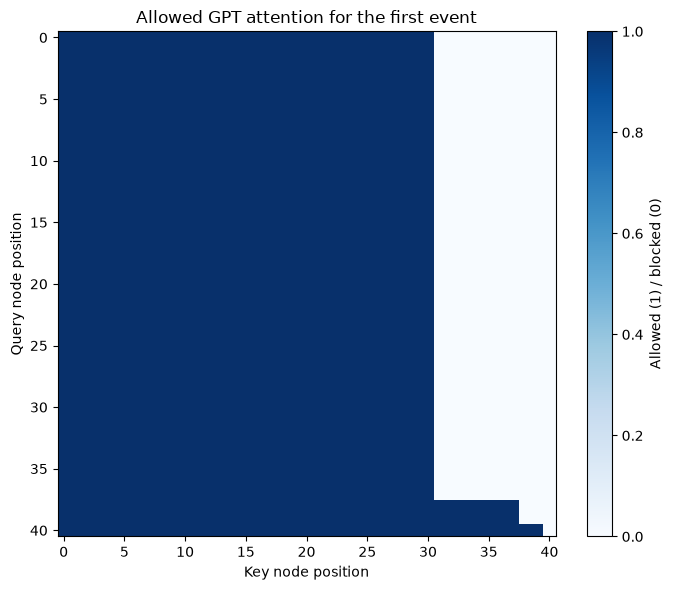

In [7]:
particle_embedder = ParticleEmbedder(
    n_features=len(DIRECT_FEATURE_NAMES),
    tr_width=16,
    tr_n_head=2,
    tr_n=1,
    tr_hidden_size=32,
    pdg_emb=4,
    dim_hyper=4,
    num_pdg=40,
    device=DEVICE,
)
particle_embeddings = particle_embedder(structure).detach()
gpt_batch = build_direct_multi_gpt_batch(particle_embeddings, structure)

first_count = int(structure["padding_mask"][0].sum())
visible_count = int((structure["level_ids"][0, :first_count] == 0).sum())
print("Particle embedding shape:", tuple(particle_embeddings.shape))
print("First event active nodes:", first_count)
print("First event visible leaf inputs:", visible_count)
print("First event masked higher-level query inputs:", first_count - visible_count)

shown = min(first_count, 50)
allowed_attention = (~gpt_batch["src_mask"][0, :shown, :shown]).numpy()
fig, axis = plt.subplots(figsize=(7, 6))
image = axis.imshow(allowed_attention, cmap="Blues", interpolation="nearest", aspect="auto")
axis.set_title("Allowed GPT attention for the first event")
axis.set_xlabel("Key node position")
axis.set_ylabel("Query node position")
fig.colorbar(image, ax=axis, label="Allowed (1) / blocked (0)")
fig.tight_layout()
plt.show()

### 7. Run MultiGPT, calculate losses, and execute one optimizer step

In [8]:
model = MultiGPT(
    rec_width=16,
    rec_n_head=2,
    rec_n=1,
    rec_hidden_size=32,
    link_width=16,
    link_n_head=2,
    link_n=1,
    link_hidden_size=32,
    dim_hyper=4,
    device=DEVICE,
)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
optimizer.zero_grad(set_to_none=True)

predicted_embeddings, predicted_links = model(gpt_batch)
active_mask = gpt_batch["lvl_code"].bool()
link_mask = gpt_batch["links"] >= 0
reconstruction_loss = distance(
    predicted_embeddings,
    gpt_batch["target"],
    active_mask,
)
link_loss, link_accuracy = link_metrics(
    predicted_links,
    gpt_batch["links"],
    link_mask,
)
radial_loss = radius_loss(
    predicted_embeddings,
    gpt_batch["mass"],
    link_mask,
)
total_loss = reconstruction_loss + link_loss + radial_loss
total_loss.backward()

finite_gradients = [
    torch.isfinite(parameter.grad).all()
    for parameter in model.parameters()
    if parameter.grad is not None
]
gradient_norm = torch.sqrt(
    sum(
        torch.sum(parameter.grad.detach() ** 2)
        for parameter in model.parameters()
        if parameter.grad is not None
    )
)
optimizer.step()

display(
    pd.Series(
        {
            "predicted embedding shape": tuple(predicted_embeddings.shape),
            "predicted link shape": tuple(predicted_links.shape),
            "reconstruction loss": float(reconstruction_loss.detach()),
            "link loss": float(link_loss.detach()),
            "link accuracy (untrained)": float(link_accuracy.detach()),
            "radial loss": float(radial_loss.detach()),
            "total loss": float(total_loss.detach()),
            "gradient L2 norm": float(gradient_norm),
            "all gradients finite": all(finite_gradients),
        },
        name="real-parquet MultiGPT smoke test",
    )
)

predicted embedding shape     (4, 58, 4)
predicted link shape         (4, 58, 58)
reconstruction loss             0.802441
link loss                       3.917716
link accuracy (untrained)            0.0
radial loss                     0.348042
total loss                      5.068199
gradient L2 norm                0.503853
all gradients finite                True
Name: real-parquet MultiGPT smoke test, dtype: object

## Checks

In [9]:
checks = {
    "schema is direct-mdst-tree-v1": payload["schema_version"] == "direct-mdst-tree-v1",
    "event provenance is unique": events_frame["event_uid"].is_unique,
    "tree p4 closure passes": max_p4_closure_error < 1e-8,
    "GPT output embeddings finite": bool(torch.isfinite(predicted_embeddings).all()),
    "GPT link scores finite": bool(torch.isfinite(predicted_links).all()),
    "loss finite": bool(torch.isfinite(total_loss)),
    "gradients finite": all(finite_gradients),
    "optimizer step completed": True,
}
display(pd.Series(checks, name="validation checks"))
assert all(checks.values())

schema is direct-mdst-tree-v1    True
event provenance is unique       True
tree p4 closure passes           True
GPT output embeddings finite     True
GPT link scores finite           True
loss finite                      True
gradients finite                 True
optimizer step completed         True
Name: validation checks, dtype: bool

## Next Steps

In [10]:
if MANIFEST_SUMMARY_PATH.exists():
    manifest_summary = json.loads(MANIFEST_SUMMARY_PATH.read_text())
    display(pd.Series(manifest_summary, name="planned large-scale production"))
else:
    print("10M-event manifest has not been generated in this environment.")

category_events    {'ccbar': 1431987, 'charged': 1114800, 'ddbar'...
events_per_task                                                25000
input_root         /pnfs/desy.de/belle/local/belle/MC/release-08-...
manifest           /data/dust/user/boyangyu/hypertagging/producti...
output_root        /data/dust/user/boyangyu/hypertagging/producti...
planned_events                                              10000000
target_events                                               10000000
tasks                                                            409
Name: planned large-scale production, dtype: object

- The production plan targets **10 million input events**, which is deliberately
  more conservative than counting level rows as training samples.
- The current adapter is suitable for integration testing and teacher-forced
  experimentation. Before a full training campaign, establish feature
  normalization, train/validation/test splits by `event_uid` and source file,
  checkpointing, and physics metrics.
- The newer set-based level-autoregressive model remains the preferred architecture
  when permutation invariance and variable output cardinality are primary goals.